# 🧬 Model Development – Immunotherapy Response Prediction
## Hackathon DIGPHAT – PharmacogenomicDay

**Use Case:** Multi-modal prediction of Immunotherapy response for ccRCC patients with follow-up post-Immune Checkpoint Blockade (ICB).

In this notebook we will:
1. Explore & integrate five omics/clinical modalities
2. Define the clinical outcome (RECIST response)
3. Preprocess each data modality (leakage-controlled)
4. Engineer features & reduce dimensionality
5. Train and evaluate multiple ML classifiers
6. Save the best model & preprocessing artifacts for the **Deployment Notebook**

In [200]:
import pandas as pd
import numpy as np
import os, warnings, joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score,cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
# from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import miceforest as mf

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
print("All imports OK ✅")

All imports OK ✅


---
# 1. Objective & Clinical Question

**Clinical question:** Can we predict RECIST response (CR/PR vs SD/PD) to immunotherapy from multi-modal patient data?

| Item | Detail |
|------|--------|
| Tumor type | Clear-cell Renal Cell Carcinoma (ccRCC) |
| Treatment | Immune Checkpoint Blockade (Nivolumab) |
| Outcome | Binary RECIST: **Responder** (CR/PR) vs **Non-Responder** (SD/PD) |
| Sites | Primary + metastatic samples |

---
# 2. Dataset Overview

## 2.1 Modalities

| # | Modality | Description |
|---|----------|-------------|
| 1 | **Clinical** | Demographics, treatment, tumour characteristics, RECIST |
| 2 | **Genomic** | Somatic mutations & copy-number alterations |
| 3 | **Immune deconvolution** | [CIBERSORTx](https://cibersortx.stanford.edu/) cell-type proportions from bulk RNA-seq |
| 4 | **Pathway scores** | ssGSEA scores for 50 [Hallmark pathways](https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H) |
| 5 | **Transcriptomic** | Gene-level TPM expression (~40 k genes) |

---
The cohort is collected from the study by Braun et al. (2020) [Nature Medicine](https://www.nature.com/articles/s41591-020-0839-y) consisting of ccRCC patients treated with Nivolumab. We split the data into a training set (80%) and a hold-out test set (20%) for final evaluation.

- The **training set** → used in this notebook for model development (with cross-validation).
- The **test set** → held out for the **Deployment Notebook** (blind evaluation).

In [2]:
#Load training data of all five modalities

clinical_train_df = pd.read_csv('Data/train/clinical.csv')
genomic_train_df = pd.read_csv('Data/train/genomic.csv')
deconv_train_df = pd.read_csv('Data/train/cell_deconvolution.csv')
ssgsea_train_df = pd.read_csv('Data/train/ssgsea.csv')
transcriptomic_train_df = pd.read_csv('Data/train/transcriptomic.csv')

# ── Quick look at each modality ───────────────────────────────────────────────
for name, df in [('Clinical', clinical_train_df), ('Genomic', genomic_train_df),
                 ('Deconvolution', deconv_train_df), ('ssGSEA', ssgsea_train_df),
                 ('Transcriptomic', transcriptomic_train_df)]:
    print(f"\n{'='*60}")
    print(f"  {name}: Shape = {df.shape}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical: Shape = (224, 11)


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,SD



  Genomic: Shape = (224, 34)


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,MUT,MUT,MUT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,MUT,WT,WT
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,WT,WT,MUT,WT,WT,WT,MUT,MUT,MUT,...,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT



  Deconvolution: Shape = (224, 27)


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.046327,0.086641,0.015842,0.185357,0.0,0.204351,0.022605,0.050186,0.009508,...,0.042027,0.021309,0.057458,0.0,0.009780,0.053686,0,0.923779,0.650795,1.274922
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.069083,0.050311,0.035438,0.101136,0.0,0.179168,0.035013,0.087914,0.000000,...,0.023344,0.019054,0.094429,0.0,0.000000,0.075189,0,0.917443,0.667743,1.304494
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.014722,0.085358,0.009111,0.049616,0.0,0.208555,0.057945,0.098924,0.000000,...,0.016985,0.005598,0.084503,0.0,0.019692,0.055920,0,0.888383,0.686416,1.163864



  ssGSEA: Shape = (224, 51)


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.645208,0.613143,0.640741,0.544471,0.477824,0.356894,0.653818,0.393865,0.589824,...,0.792464,0.729333,0.128080,0.670299,0.571636,0.717934,0.662968,0.512491,0.432010,0.477736
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.745334,0.481716,0.692472,0.656193,0.583043,0.523270,0.671667,0.518503,0.672382,...,0.821810,0.773135,0.139733,0.745215,0.604999,0.734874,0.713620,0.574449,0.514951,0.629333
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.756409,0.462137,0.704921,0.596222,0.552728,0.398848,0.646143,0.456058,0.698500,...,0.822478,0.756662,0.131104,0.769317,0.582469,0.764036,0.716527,0.572508,0.487859,0.532403



  Transcriptomic: Shape = (224, 40935)


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,22.45228,34.75424,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,26.08813,33.57834,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,22.45228,34.02825,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162


## 2.2. Data Description

In [3]:
# ── Training data summary ────────────────────────────────────────────────────────────
print(f"Total patients: {len(clinical_train_df)}")
print(f"\nORR distribution:")
print(clinical_train_df['ORR'].value_counts().to_string())
print(f"\nCohorts: {clinical_train_df['Cohort'].unique()}")
print(f"Treatment arms: {clinical_train_df['Arm'].unique()}")

Total patients: 224

ORR distribution:
ORR
SD      100
PD       89
CRPR     24
PR       10
CR        1

Cohorts: ['CM-010' 'CM-025' 'CM-009']
Treatment arms: ['NIVOLUMAB' 'EVEROLIMUS']


### 2.2.1. Outcome Definition
We define a **binary** outcome for immunotherapy response:
- **1 (Responder):** CR (Complete Response), PR (Partial Response), CRPR
- **0 (Non-Responder):** SD (Stable Disease), PD (Progressive Disease)

,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR,Response
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD,0
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR,1
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,SD,0


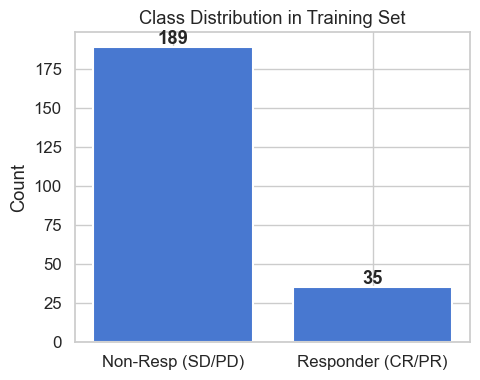

Responders: 35  |  Non-Responders: 189  |  Ratio: 1:5.4


In [4]:
# Map ORR to binary label
response_map = {'CR': 1, 'PR': 1, 'CRPR': 1, 'SD': 0, 'PD': 0}
clinical_train_df['Response'] = clinical_train_df['ORR'].map(response_map)
display(clinical_train_df.head(3))

resp_counts = clinical_train_df['Response'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Non-Resp (SD/PD)', 'Responder (CR/PR)'], resp_counts.values, edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution in Training Set')
plt.tight_layout(); plt.show()

ratio = resp_counts[1] / resp_counts[0]
print(f"Responders: {resp_counts[1]}  |  Non-Responders: {resp_counts[0]}  |  Ratio: 1:{1/ratio:.1f}")

### 2.2.2 Missing Data

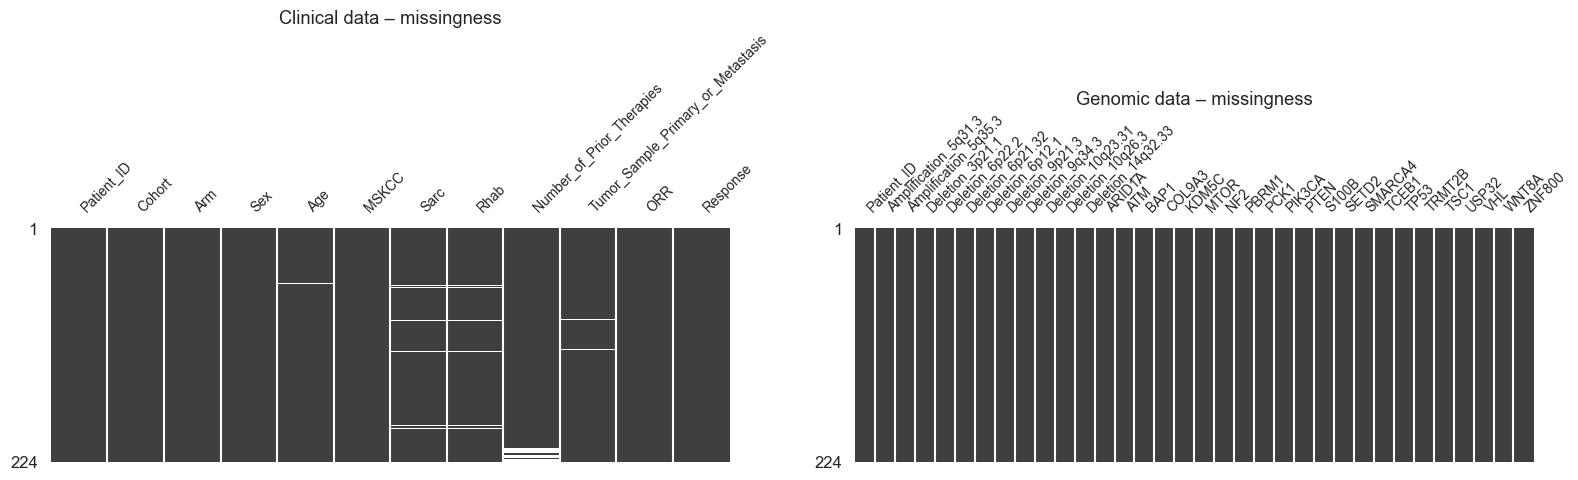

Total missing values in transcriptomic data: 0


In [5]:
fig, axes = plt.subplots(1,2, figsize=(16, 5))
msno.matrix(clinical_train_df, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Clinical data – missingness')
msno.matrix(genomic_train_df.iloc[:, :34], ax=axes[1], sparkline=False, fontsize=10)
axes[1].set_title('Genomic data – missingness')
plt.tight_layout()
plt.show()

print(f"Total missing values in transcriptomic data: {transcriptomic_train_df.isna().sum().sum()}")

# 3. Data Preprocessing & Feature Engineering

> **Leakage-controlled:** Every transformation (scaling, imputation, PCA, feature
> selection) is **fit on the training set only** and later applied to the test set
> in the Deployment Notebook.

## 3.1 Transcriptomic Data (RNA-seq)

The expression matrix contains **~40 000 genes** measured in **TPM** (Transcripts Per Million).

**Pre-processing steps:**
- The data is **already normalised to TPM**.
- We **filter low-expression genes** by removing genes below a variance threshold.
- We **standardise** the remaining genes.
- Sometimes, Gene identifiers are Ensembl IDs (e.g. `ENSG00000141510.18`).
  In a production pipeline you would convert them to HUGO symbols (`mygene` library, etc.). Here we keep Ensembl IDs for simplicity.

In [6]:
# ── 4.1  Transcriptomic processing ────────────────────────────────────────────
train_trans = transcriptomic_train_df.drop('Patient_ID', axis=1).copy()

# Filter low-expression genes  (under variance threshold)
gene_var = train_trans.var()
var_cutoff = 0.05 #we can also use quantile-based cutoff (e.g. top 50% variance)
keep_genes = gene_var[gene_var > var_cutoff].index.tolist()
train_trans = train_trans[keep_genes]
print(f"Genes kept after variance filter: {len(keep_genes)} / {len(gene_var)}")


# Standardise
trans_scaler = StandardScaler()
train_trans_scaled = pd.DataFrame(
    trans_scaler.fit_transform(train_trans),
    columns=keep_genes
)
print(f"Transcriptomic feature matrix: {train_trans_scaled.shape}")

Genes kept after variance filter: 38030 / 40934
Transcriptomic feature matrix: (224, 38030)


## 3.2 Somatic Mutation Data

The genomic dataset contains somatic **mutation status** and **copy-number alterations**.

Values: `MUT` (mutated) / `WT` (wild-type) / **`NO_IF`** (no information).

We can treat these as categorical features, but we need to handle the `NO_IF` values carefully. We can consider it as missing values or as a separate category depending on the context. At the first step, we won't use this information in our model, but you can try to play with it.

## 3.3 ssGSEA Pathway Scores (Hallmark)

50 Hallmark pathway enrichment scores computed with [GSEAPy](https://gseapy.readthedocs.io/).
```python
import gseapy as gp
# txt, gct file input
ss = gp.ssgsea(data='./tests/extdata/Leukemia_hgu95av2.trim.txt',
               gene_sets='./tests/extdata/h.all.v7.0.symbols.gmt',
               outdir=None,
               sample_norm_method='rank', # choose 'custom' will only use the raw value of `data`
               no_plot=True)
```
We **standardise** them (zero mean, unit variance) before model training.

In [7]:
# ── 4.4  Pathway scaling ───────────────────────────────────────────────────────
train_pathway = ssgsea_train_df.drop('Patient_ID', axis=1).copy()
pathway_scaler = StandardScaler()
train_pathway_scaled = pd.DataFrame(
    pathway_scaler.fit_transform(train_pathway),
    columns=train_pathway.columns
)
print(f"Pathway features: {train_pathway_scaled.shape[1]}")

Pathway features: 50


## 3.4 Immune Cell Deconvolution (CIBERSORTx)

Cell-type proportions estimated from bulk RNA-seq. We leverage the [CIBERSORTx](https://cibersortx.stanford.edu/) tool to deconvolve bulk transcriptomic data into immune cell-type proportions. The output consists of relative abundances of various immune cell types (e.g., CD8+ T cells, macrophages, etc.) for each sample. 

We used LM22 signature matrix for deconvolution, which includes 22 immune cell types. The resulting cell-type proportions are compositional data (i.e., they sum to 1 for each sample).

Since these are **compositional data** (proportions summing to ~1), we apply a **centered-logratio (CLR) transform**.

In [102]:
cell_cols = [
    c for c in deconv_train_df.columns
    if c not in ["Patient_ID", "P-value", "Correlation", "RMSE", "Absolute score (sig.score)"]
]

X = deconv_train_df[cell_cols].copy()

# Small epsilon to avoid log(0)
eps = 1e-6
X_eps = X + eps

# Geometric mean per sample (row)
geo_mean = np.exp(np.log(X_eps).mean(axis=1))

# CLR: log(x / g(x)) for each row
clr_values = np.log(X_eps.div(geo_mean, axis=0))
deconv_clr_df = pd.DataFrame(clr_values, columns=cell_cols)

#Scaled CLR values
clr_scaler = StandardScaler()
deconv_clr_scaled = clr_scaler.fit_transform(deconv_clr_df)
deconv_clr_df = pd.DataFrame(deconv_clr_scaled, columns=cell_cols)


display(deconv_clr_df.head(3))

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,-0.180077,-0.156633,-0.027753,-0.249186,-0.573604,-0.726541,-0.018866,-2.105710,1.259640,0.872660,...,-1.934257,0.763863,-0.742317,-1.256990,0.107029,-0.81205,0.126820,-1.969689,0.321535,0.037507
1,0.627546,0.214808,0.741639,0.269699,0.078430,0.697218,0.514127,0.617571,-0.678991,0.795649,...,1.264156,-1.340876,1.129417,0.670025,0.415557,-0.02384,0.703849,-1.682839,-1.822439,0.855310
2,0.157457,0.860008,0.456281,0.184232,0.411702,1.716522,0.877653,1.749014,-0.529414,-0.909790,...,1.190554,-1.200217,1.821545,1.677629,0.564447,-0.46562,0.874766,-1.536221,0.996713,1.024371


## 3.5 Clinical Data

- **Categorical variables** (Arm) → one-hot encoding

- **Ordinal variables** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding

- **Binary variables** (Sarc, Rhab, Sex, Tumor_Sample_Primary_or_Metastasis) → binary encoding

- **Numerical variables** (Age) → standardisation


Missing values before imputation: 64


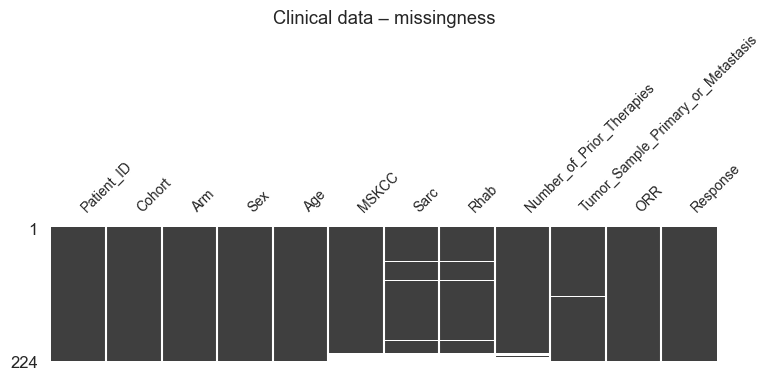

In [44]:
# Replace NO-IF with NaN for Sarc and Rhab and MSKCC
for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinical_train_df[col] = clinical_train_df[col].replace('NO_IF', np.nan)

missing_before = clinical_train_df.isna().sum().sum()
print(f"Missing values before imputation: {missing_before}")
#Visualize missingness in clinical data 
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(clinical_train_df, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical data – missingness')
plt.tight_layout()
plt.show()  

In [45]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Drop Cohort column
train_clinic = clinical_train_df.drop(columns=['Cohort']).copy()
# ── Define column groups ───────────────────────────────────────────────────────
dummy_cols = ['Arm']                           # One-hot encoding
binary_cols = ['Sex', 'Sarc', 'Rhab', 'Tumor_Sample_Primary_or_Metastasis']  # Binary
ordinal_cols = ['MSKCC', 'Number_of_Prior_Therapies']  # Ordinal encoding
num_cols = ['Age']                             # Standardization

# Storage for transformers (to apply later on test/external data)
transformers = {}
# ── 1. One-Hot Encoding for 'Arm' ─────────────────────────────────────────────
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
arm_encoded = ohe.fit_transform(train_clinic[[dummy_cols[0]]])
arm_df = pd.DataFrame(
    arm_encoded, 
    columns=ohe.get_feature_names_out([dummy_cols[0]]),
    index=train_clinic.index
)
transformers['ohe_Arm'] = ohe

In [46]:
# ── 2. Binary Encoding ────────────────────────────────────────────────────────
# Simple 0/1 encoding (assumes values like 'Male/Female', 'Yes/No', etc.)
binary_encoded = train_clinic[binary_cols].copy()
for col in binary_cols:
    le = LabelEncoder()
    binary_encoded[col] = le.fit_transform(binary_encoded[col].astype(str))
    transformers[f'le_{col}'] = le

In [70]:
# ── 3. Ordinal Encoding ───────────────────────────────────────────────────────
# MSKCC: FAVORABLE > INTERMEDIATE > POOR
# Number_of_Prior_Therapies: already numeric, but treat as ordinal
mskcc_order = [['POOR', 'INTERMEDIATE', 'FAVORABLE', np.nan]] 
ordinal_encoded = train_clinic[ordinal_cols].copy()
# MSKCC - ordinal
mskcc_oe = OrdinalEncoder(categories=mskcc_order, handle_unknown='use_encoded_value', unknown_value=-1,encoded_missing_value=np.nan)
ordinal_encoded['MSKCC'] = mskcc_oe.fit_transform(ordinal_encoded[['MSKCC']])
transformers['oe_MSKCC'] = mskcc_oe

In [71]:
# ── 4. Numerical Scaling ─────────────────────────────────────────────────────
age_scaled = train_clinic[num_cols].copy()
scaler = StandardScaler()
age_scaled[num_cols] = scaler.fit_transform(age_scaled[num_cols])
transformers['scaler_Age'] = scaler

In [95]:
# ── Combine all encoded features ──────────────────────────────────────────────
train_clinical_encoded = pd.concat([
    train_clinic[['Response']],  
    arm_df,
    binary_encoded,
    ordinal_encoded,
    age_scaled
], axis=1)

display(train_clinical_encoded.head(3))
print(f"\nEncoded clinical shape: {train_clinical_encoded.shape}")

,Response,Arm_EVEROLIMUS,Arm_NIVOLUMAB,Sex,Sarc,Rhab,Tumor_Sample_Primary_or_Metastasis,MSKCC,Number_of_Prior_Therapies,Age
0,0,0.0,1.0,1,0,0,1,2.0,2.0,0.041661
1,1,0.0,1.0,0,0,0,1,0.0,1.0,0.041661
2,0,0.0,1.0,1,0,0,1,1.0,2.0,1.455420



Encoded clinical shape: (224, 10)


### 3.5.1. Handling Missing Values in Clinical Data

We impute missing values using **MICE** (Multiple Imputation by Chained Equations) via the `miceforest` library.

In [96]:
kernel = mf.ImputationKernel(train_clinical_encoded, random_state=RANDOM_STATE)
kernel.mice(iterations=10, verbose=False)
train_clinical_imputed = kernel.complete_data()

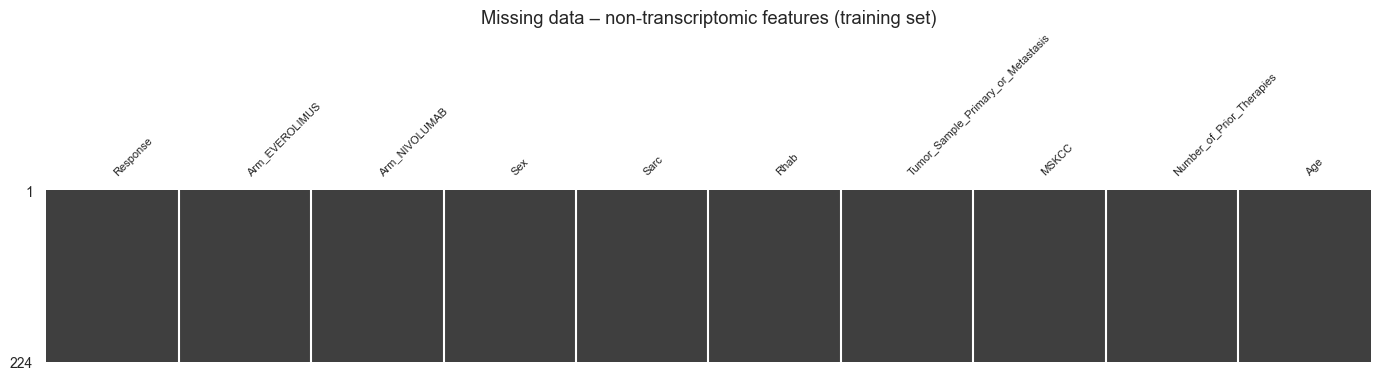

In [97]:
msno.matrix(train_clinical_imputed, figsize=(14, 4), sparkline=False, fontsize=8)
plt.title('Missing data – non-transcriptomic features (training set)')
plt.tight_layout()
plt.show()

train_clinical_processed = pd.concat([
    train_clinic[['Patient_ID']],
    train_clinical_imputed], axis=1)

## **3.6. Integrate all preprocessed features**

In [106]:
df_train_all = pd.concat([
    train_clinical_processed,
    train_trans_scaled,
    train_pathway_scaled,
    deconv_clr_df], axis=1)
display(df_train_all.head())

,Patient_ID,Response,Arm_EVEROLIMUS,Arm_NIVOLUMAB,Sex,Sarc,Rhab,Tumor_Sample_Primary_or_Metastasis,MSKCC,Number_of_Prior_Therapies,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,2.0,2.0,...,-1.934257,0.763863,-0.742317,-1.256990,0.107029,-0.812050,0.126820,-1.969689,0.321535,0.037507
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,1,0.0,1.0,0,0,0,1,0.0,1.0,...,1.264156,-1.340876,1.129417,0.670025,0.415557,-0.023840,0.703849,-1.682839,-1.822439,0.855310
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,1.0,2.0,...,1.190554,-1.200217,1.821545,1.677629,0.564447,-0.465620,0.874766,-1.536221,0.996713,1.024371
3,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0,0.0,1.0,0,0,0,1,2.0,3.0,...,0.758421,0.383159,1.046238,0.528261,0.213166,-0.254659,0.357321,-1.733791,0.082008,0.685181
4,G138701_RCCBMS-00116-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,0.0,2.0,...,-0.851817,0.679393,-1.440730,-1.208248,0.096057,-0.149482,0.147502,0.342260,0.476714,-0.139792


# **4. Feature Selection & Dimensionality Reduction**

In [147]:
X_train_final = df_train_all.drop(columns=['Patient_ID', 'Response'])
y_train = df_train_all['Response']

## **4.1. Embedded Methods**
We use **L2-regularised Logistic Regression** to perform embedded feature selection. The `SelectFromModel` class from `sklearn` allows us to select features based on the importance weights learned by the logistic regression model.

In [199]:
model = LogisticRegression(penalty='l1', C=0.1, random_state=RANDOM_STATE,solver='saga')
model.fit(X_train_final, y_train)
selector = SelectFromModel(model, prefit=True)

X_train_sel = selector.transform(X_train_final)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")

Original feature count: 38111
Selected feature count: 701


## **4.2. Wrapper Methods**
We can also use **Recursive Feature Elimination (RFE)** with a logistic regression estimator to iteratively select features by recursively considering smaller and smaller sets of features.
```python
from sklearn.feature_selection import RFE
estimator = LogisticRegression(penalty='l2', C=0.1, random_state=RANDOM_STATE)
selector = RFE(estimator, n_features_to_select=20, step=1)
selector = selector.fit(X_train_final, y_train)
X_train_sel = selector.transform(X_train_final)
```

## **4.3. Dimensionality Reduction with PCA**
We can apply **Principal Component Analysis (PCA)** to reduce the dimensionality of the transcriptomic features while retaining most of the variance. We can select the number of principal components based on the cumulative explained variance (e.g., retaining 95% of the variance).
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(X_train_transcriptomic_scaled) 
```

# **5. Model Training & Evaluation**

We train classifiers using **Stratified K-Fold Cross-Validation** on the training set.

## 5.1 Baseline: Penalised Logistic Regression
Provides interpretability and well-calibrated probabilities.

In [189]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'bal_acc':   'balanced_accuracy',
    'f1':        'f1',
    'mcc':       'matthews_corrcoef',
}
model = LogisticRegression(penalty='l2', C=1.0, max_iter=5000, random_state=RANDOM_STATE)

for score in scoring.values():
    cv_res = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring=score, n_jobs=-1)
    print(f"{score:25s}  {cv_res.mean():.3f}±{cv_res.std():.3f}")

roc_auc                    1.000±0.000
average_precision          1.000±0.000
balanced_accuracy          0.921±0.100
f1                         0.900±0.134
matthews_corrcoef          0.899±0.130


In [ ]:
# Feature importance from logistic regression coefficients
model.fit(X_train_sel, y_train)
feature_importance = np.abs(model.coef_[0])
feature_names = X_train_final.columns[selector.get_support()]
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
display(feat_imp_df.head(10))

,Feature,Importance
666,ENSG00000183066.14,0.111275
547,ENSG00000259813.1,0.107436
365,ENSG00000270369.1,0.107369
358,ENSG00000229124.7,0.105836
109,ENSG00000183396.4,0.098840
571,ENSG00000250838.1,0.097414
697,ENSG00000147378.11,0.095580
579,ENSG00000267731.1,0.095245
352,ENSG00000179082.3,0.094939
173,ENSG00000197465.14,0.093094


## **5.2. Learning Curves**
A learning curve helps diagnose **overfitting** (large train–test gap) and
**underfitting** (both curves plateau at low score).

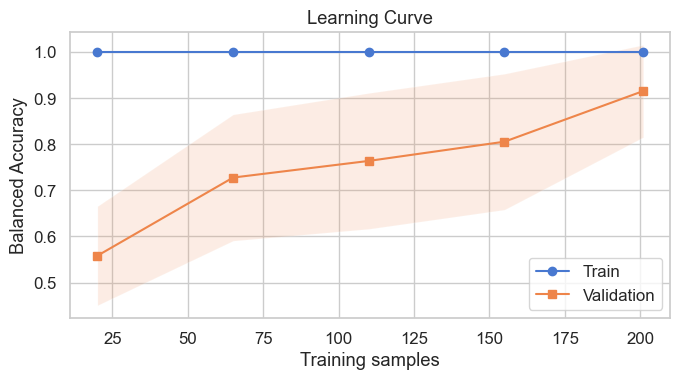

In [183]:
# ── 6.3  Learning curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_sel, y_train, cv=cv, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE)

ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1),   's-', label='Validation')
ax.fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15)
ax.fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15)
ax.set_xlabel('Training samples'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('Learning Curve'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

Now we will try on other models such as Random Forest, SVM etc.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        penalty='l2', C=1.0, max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    cv_res = cross_validate(model, X_train_sel, y_train, cv=cv,
                            scoring=scoring, return_train_score=False, n_jobs=-1)
    results[name] = cv_res
    print(f"{name:25s}  ROC-AUC={cv_res['test_roc_auc'].mean():.3f}±{cv_res['test_roc_auc'].std():.3f}"
          f"  PR-AUC={cv_res['test_pr_auc'].mean():.3f}±{cv_res['test_pr_auc'].std():.3f}"
          f"  BalAcc={cv_res['test_bal_acc'].mean():.3f}  F1={cv_res['test_f1'].mean():.3f}"
          f"  MCC={cv_res['test_mcc'].mean():.3f}")

Logistic Regression        ROC-AUC=1.000±0.000  PR-AUC=1.000±0.000  BalAcc=0.921  F1=0.900  MCC=0.899
Random Forest              ROC-AUC=0.874±0.092  PR-AUC=0.696±0.179  BalAcc=0.522  F1=0.067  MCC=0.073
SVM                        ROC-AUC=0.985±0.027  PR-AUC=0.952±0.081  BalAcc=0.881  F1=0.823  MCC=0.821


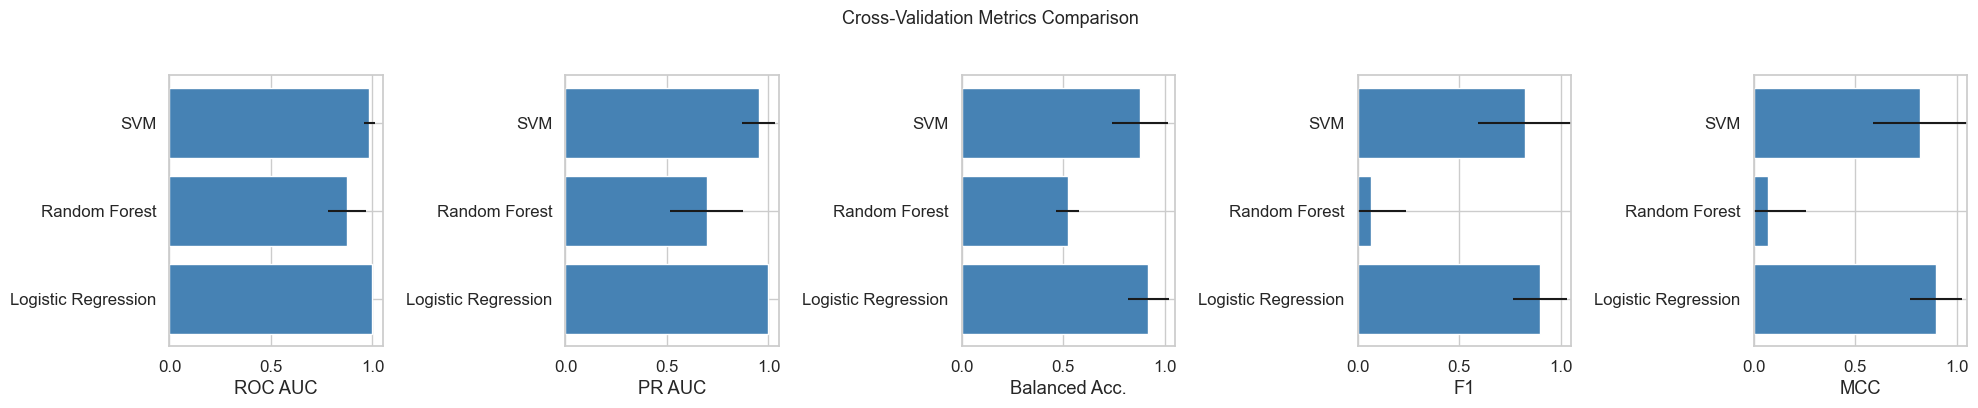

In [186]:
# ── 6.1b  Bar chart comparison ────────────────────────────────────────────────
metrics = ['test_roc_auc', 'test_pr_auc', 'test_bal_acc', 'test_f1', 'test_mcc']
metric_labels = ['ROC AUC', 'PR AUC', 'Balanced Acc.', 'F1', 'MCC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for ax, m, ml in zip(axes, metrics, metric_labels):
    means = [results[n][m].mean() for n in model_names]
    stds  = [results[n][m].std()  for n in model_names]
    ax.barh(model_names, means, xerr=stds, color='steelblue', edgecolor='white')
    ax.set_xlabel(ml); ax.set_xlim(0, 1.05)
plt.suptitle('Cross-Validation Metrics Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
# **6. Save Model & Preprocessing Artifacts**

All fitted objects are saved so the **Deployment Notebook** can apply the
exact same pipeline to the held-out test set.

In [201]:
os.makedirs('artifacts', exist_ok=True)

#Artifact dictionary to save all fitted objects and metadata for deployment

artifacts = {
    'model':             model,
    'model_name':        'Logistic Regression',
    'encoders':          transformers,
    'keep_genes':        keep_genes,
    'num_cols':           num_cols,
    'binary_cols':        binary_cols,
    'ordinal_cols':       ordinal_cols,
    'mice_kernel':        kernel,
}
joblib.dump(artifacts, 'artifacts/pipeline_artifacts.joblib')
print("Artifacts saved to artifacts/pipeline_artifacts.joblib")
print(f"   Model: {LogisticRegression.__name__}")
print(f"   Features: {X_train_sel.shape[1]} total")

Artifacts saved to artifacts/pipeline_artifacts.joblib
   Model: LogisticRegression
   Features: 701 total


---
# **7. Ideas for Model Improvement**

Here are strategies you can explore to push performance further:

| Strategy | Description |
|----------|-------------|
| **SMOTE** | Synthetic Minority Oversampling to handle class imbalance (`imblearn.over_sampling.SMOTE`) |
| **Hyperparameter tuning** | `GridSearchCV` or `Optuna` for systematic search |
| **Feature selections** | Try different feature selection techniques (e.g., RFE, SelectKBest, [ROOFs](https://gitlab.inria.fr/compo/roofs)) |
| **Ensemble methods** | Stacking, blending multiple base models |


> 💡 **Exercise for students:** Pick one strategy above, implement it,
> and compare CV metrics before vs. after.